# Concaténation des fichiers Sales Data
Lecture et fusion des fichiers EF 2020–2024 en un seul DataFrame.

In [1]:
import pandas as pd
import os
from openpyxl.styles.named_styles import _NamedCellStyle

# Patch openpyxl bug (biltinId vs builtinId)
_orig_init = _NamedCellStyle.__init__
def _patched_init(self, *args, **kwargs):
    if 'biltinId' in kwargs:
        kwargs['builtinId'] = kwargs.pop('biltinId')
    _orig_init(self, *args, **kwargs)
_NamedCellStyle.__init__ = _patched_init

In [2]:
folder = 'Sales Data'
files = sorted([f for f in os.listdir(folder) if f.endswith('.xlsx') and 'Combined' not in f and f != 'EF 2020.xlsx'])
print(f"Fichiers trouvés: {files}")

dfs = []
for f in files:
    path = os.path.join(folder, f)
    df = pd.read_excel(path)
    print(f"  {f}: {len(df)} lignes, {len(df.columns)} colonnes")
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"\nTotal combiné: {len(combined)} lignes")

Fichiers trouvés: ['EF 2021.xlsx', 'EF 2022.xlsx', 'EF 2023.xlsx', 'EF 2024.xlsx']
  EF 2021.xlsx: 16921 lignes, 22 colonnes
  EF 2022.xlsx: 13891 lignes, 22 colonnes
  EF 2023.xlsx: 14421 lignes, 22 colonnes
  EF 2024.xlsx: 16001 lignes, 22 colonnes

Total combiné: 61234 lignes


In [3]:
combined.to_excel(os.path.join(folder, 'Combined_Sales_Data.xlsx'), index=False)

## Aperçu du DataFrame combiné

In [ ]:
dfs[0].describe()

,Quantité,Montant,N° Bon,Date Exp.,Date Fact.,Nature Art,Delai Prev,Date Cde,PU Net,Cpte vente
count,35926.000000,35926.000000,35926.000000,35926,35926,35926.0,35926,34361,35926.000000,0.0
mean,1234.675841,899.229299,55888.017007,2020-10-09 03:19:41.428492032,2020-10-09 15:32:33.415353856,6.0,2020-10-12 07:05:38.094972928,2020-09-30 13:48:51.358225920,441.779785,NaN
min,-49248.000000,-32011.200000,51535.000000,2020-03-23 00:00:00,2020-04-06 00:00:00,6.0,2019-11-15 00:00:00,2019-10-28 00:00:00,0.000000,NaN
25%,70.000000,59.640000,54619.000000,2020-07-06 00:00:00,2020-07-06 00:00:00,6.0,2020-07-03 00:00:00,2020-06-26 00:00:00,0.580000,NaN
50%,256.000000,188.000000,55851.000000,2020-10-12 00:00:00,2020-10-12 00:00:00,6.0,2020-10-09 00:00:00,2020-10-02 00:00:00,500.000000,NaN
75%,720.000000,516.000000,57139.000000,2021-01-15 00:00:00,2021-01-18 00:00:00,6.0,2021-01-14 00:00:00,2021-01-07 00:00:00,800.000000,NaN
max,99200.000000,90126.290000,58569.000000,2021-03-31 00:00:00,2021-03-31 00:00:00,6.0,2200-04-30 00:00:00,2021-03-29 00:00:00,14900.000000,NaN
std,3911.006933,3134.205837,1491.542110,NaN,NaN,0.0,NaN,NaN,536.784551,NaN


In [ ]:
dfs[1].describe()

,Quantité,Montant,N° Bon,Date Exp.,Date Fact.,Nature Art,Delai Prev,Date Cde,PU Net
count,16921.000000,16921.000000,16921.000000,16921,16921,16921.000000,14186,10943,16921.000000
mean,208.530152,174.935185,60983.478341,2021-09-23 22:28:46.280952832,2021-09-24 11:37:54.971928064,3.338751,2021-09-22 15:09:00.532919552,2021-09-12 13:32:42.350361088,181.828102
min,-2910.000000,-72682.630000,55590.000000,2021-04-06 00:00:00,2021-04-06 00:00:00,1.000000,2021-01-13 00:00:00,2020-10-14 00:00:00,0.000000
25%,0.000000,0.000000,59690.000000,2021-06-21 00:00:00,2021-06-21 00:00:00,2.000000,2021-06-16 00:00:00,2021-06-04 00:00:00,0.000000
50%,6.000000,0.000000,60930.000000,2021-09-23 00:00:00,2021-09-24 00:00:00,2.000000,2021-09-19 00:00:00,2021-09-09 00:00:00,0.010000
75%,40.000000,12.000000,62284.000000,2021-12-22 00:00:00,2021-12-23 00:00:00,5.000000,2021-12-23 00:00:00,2021-12-16 00:00:00,300.000000
max,53037.000000,54557.000000,63720.000000,2022-09-30 00:00:00,2022-03-31 00:00:00,8.000000,2022-10-31 00:00:00,2022-03-28 00:00:00,72682.630000
std,1377.542114,1473.135818,1511.242921,NaN,NaN,2.034895,NaN,NaN,786.935393


In [ ]:
dfs[2].describe()

,Quantité,Montant,N° Bon,Date Exp.,Date Fact.,Nature Art,Delai Prev,Date Cde,PU Net
count,13891.000000,13891.000000,13891.000000,13891,13891,13891.000000,11282,8696,13891.000000
mean,199.454328,147.327023,65659.346483,2022-09-24 05:24:46.804405504,2022-09-24 17:47:44.502195712,3.465913,2022-09-20 01:52:34.547066112,2022-09-09 20:13:18.160073728,200.279621
min,-1552.000000,-112593.820000,52178.000000,2022-01-03 00:00:00,2022-04-04 00:00:00,1.000000,2021-11-12 00:00:00,2021-10-12 00:00:00,0.000000
25%,0.000000,0.000000,64513.000000,2022-06-16 00:00:00,2022-06-16 00:00:00,2.000000,2022-06-10 00:00:00,2022-05-31 00:00:00,0.000000
50%,10.000000,0.000000,65565.000000,2022-09-20 00:00:00,2022-09-21 00:00:00,2.000000,2022-09-13 00:00:00,2022-09-06 00:00:00,0.040000
75%,40.000000,12.800000,66776.000000,2023-01-02 00:00:00,2023-01-02 00:00:00,5.000000,2022-12-23 00:00:00,2022-12-15 00:00:00,395.000000
max,87215.000000,70000.000000,68125.000000,2023-03-31 00:00:00,2023-03-31 00:00:00,8.000000,2023-04-03 00:00:00,2023-03-28 00:00:00,112593.820000
std,1647.116728,1628.715243,1364.295402,NaN,NaN,2.084027,NaN,NaN,1313.442853


## Évolution temporelle d'une variable
Choisir entre `Quantité`, `Montant` ou `PU Net` pour visualiser l'évolution dans le temps.

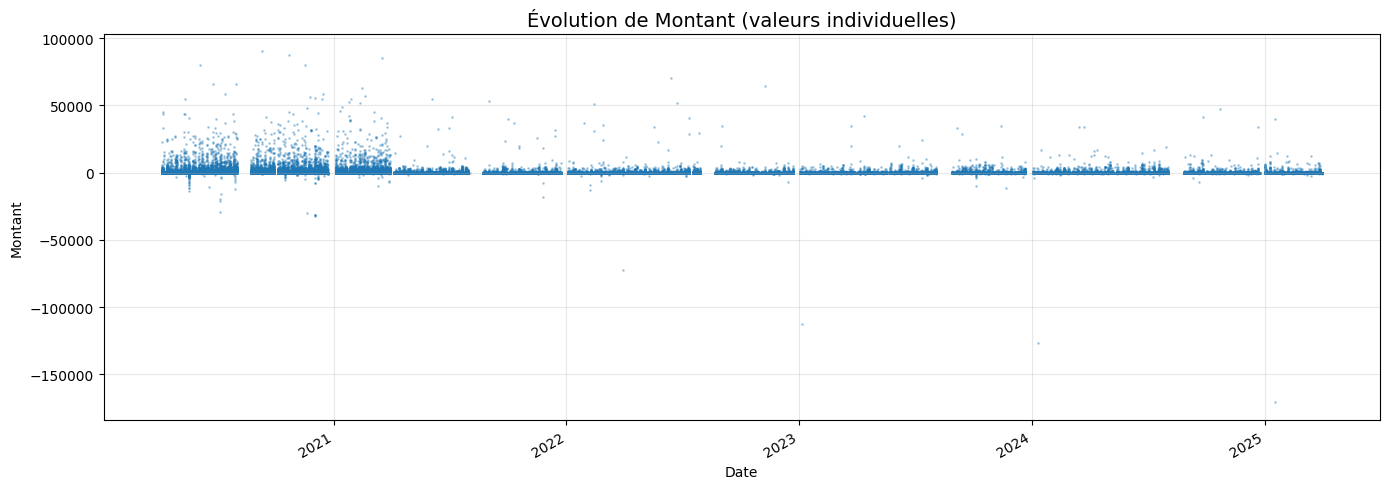

In [ ]:
import matplotlib.pyplot as plt

# === CHOISIR LA VARIABLE ===
variable = 'Montant'  # 'Quantité', 'Montant' ou 'PU Net'

# === CHOISIR LA COLONNE DE DATE ===
date_col = 'Date Fact.'  # 'Date Exp.', 'Date Fact.' ou 'Date Cde'

df_plot = combined.copy()
df_plot[date_col] = pd.to_datetime(df_plot[date_col], errors='coerce')
df_plot = df_plot.dropna(subset=[date_col, variable])
df_plot = df_plot.sort_values(date_col)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_plot[date_col], df_plot[variable], s=1, alpha=0.3)
ax.set_title(f"Évolution de {variable} (valeurs individuelles)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel(variable)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Distribution par année (fichiers individuels)
Compare la distribution d'une variable pour chaque fichier/année côte à côte.

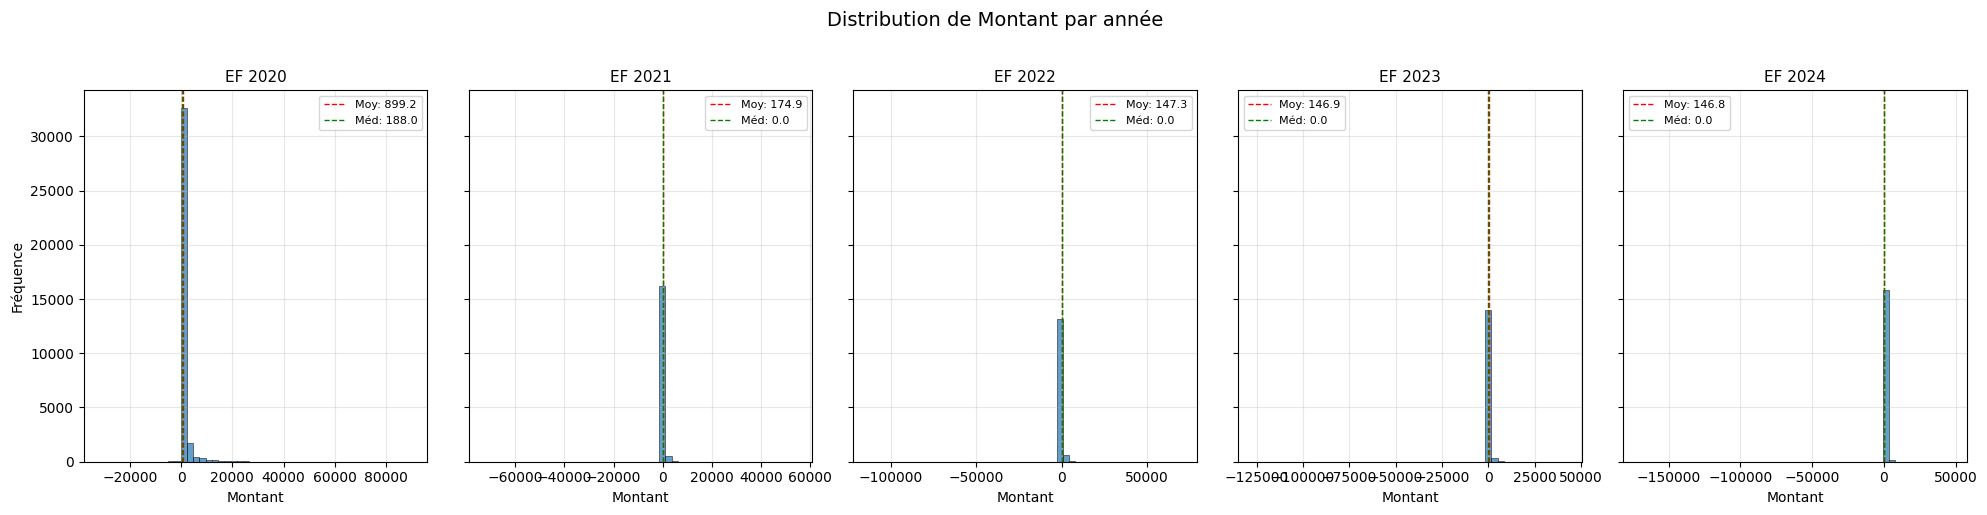

In [ ]:
# === CHOISIR LA VARIABLE ===
variable = 'Montant'  # 'Quantité', 'Montant' ou 'PU Net'

n = len(dfs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=True)

for i, (df_i, fname) in enumerate(zip(dfs, files)):
    ax = axes[i]
    data = pd.to_numeric(df_i[variable], errors='coerce').dropna()
    ax.hist(data, bins=50, edgecolor='black', linewidth=0.5, alpha=0.7)
    ax.set_title(fname.replace('.xlsx', ''), fontsize=11)
    ax.set_xlabel(variable)
    if i == 0:
        ax.set_ylabel('Fréquence')
    ax.grid(True, alpha=0.3)
    # Afficher stats
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1, label=f'Méd: {data.median():.1f}')
    ax.legend(fontsize=8)

fig.suptitle(f"Distribution de {variable} par année", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Courbe temporelle par année (fichiers individuels)
Scatter plot sans agrégation pour chaque fichier/année côte à côte.

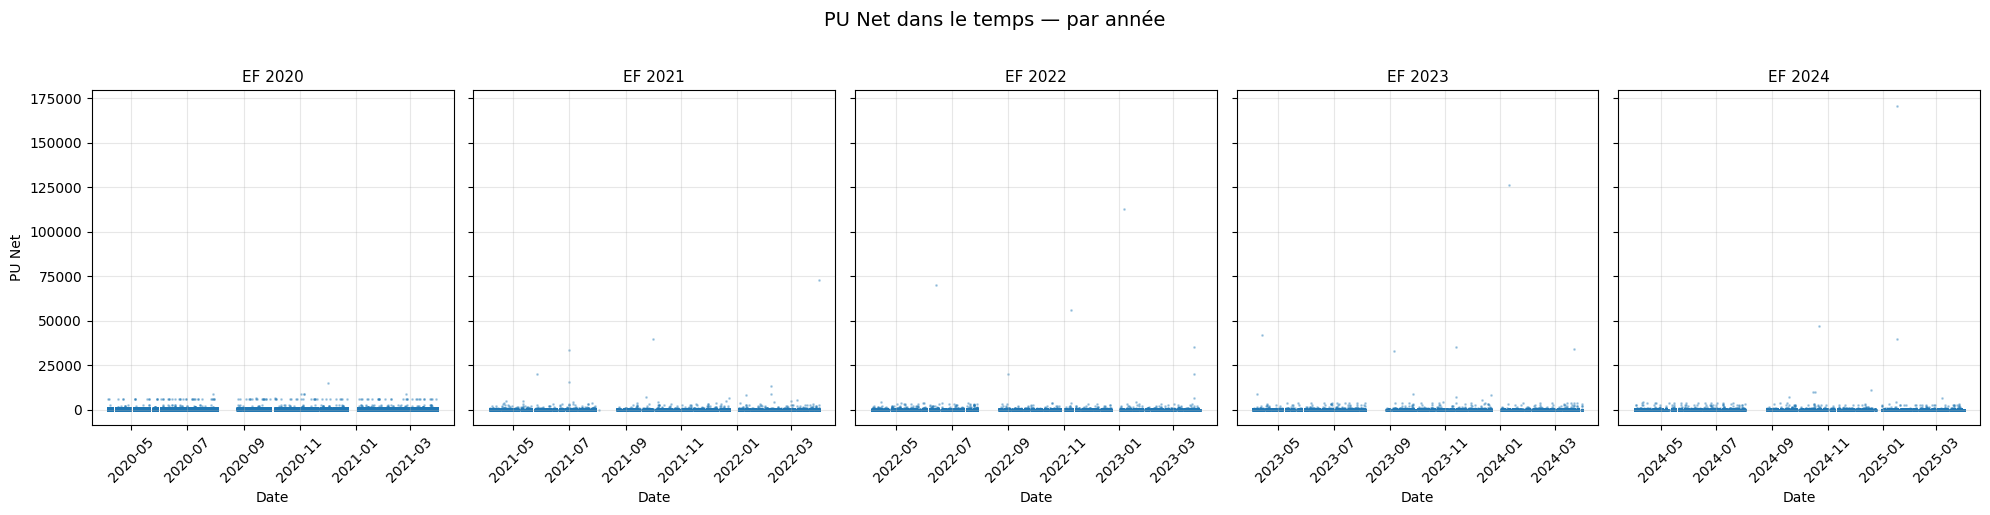

In [ ]:
# === CHOISIR LA VARIABLE ===
variable = 'PU Net'  # 'Quantité', 'Montant' ou 'PU Net'

# === CHOISIR LA COLONNE DE DATE ===
date_col = 'Date Fact.'  # 'Date Exp.', 'Date Fact.' ou 'Date Cde'

n = len(dfs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=True)

for i, (df_i, fname) in enumerate(zip(dfs, files)):
    ax = axes[i]
    tmp = df_i.copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors='coerce')
    tmp = tmp.dropna(subset=[date_col, variable]).sort_values(date_col)
    ax.scatter(tmp[date_col], tmp[variable], s=1, alpha=0.3)
    ax.set_title(fname.replace('.xlsx', ''), fontsize=11)
    ax.set_xlabel("Date")
    if i == 0:
        ax.set_ylabel(variable)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f"{variable} dans le temps — par année", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()